In [24]:
# import muon
import numpy as np
import mudata as md
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd

# clustering
from sklearn.cluster import KMeans

In [25]:
from graph import graph_construction
mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
mdata

/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 2492 × 1267
  2 modalities
    RNA:	2492 x 984
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    Protein:	2492 x 283
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

In [9]:
from sklearn.neighbors import NearestNeighbors
rna_adata = mdata.mod['RNA']
coords = rna_adata.obsm['pos'] # or 'spatial'

# 2. Find distance to the CLOSEST neighbor for every cell (k=2 includes the cell itself)
nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
distances, indices = nbrs.kneighbors(coords)

nearest_dist = distances[:, 1]
mean_dist = np.mean(nearest_dist)
p90_dist = np.percentile(nearest_dist, 90)

print(f"Avg distance to nearest neighbor: {mean_dist:.2f}")
print(f"90% of cells have a neighbor within: {p90_dist:.2f}")
# r_small  = connect immediate neighbors (~mean_dist * 1.5)
# r_medium = connect local niche (~mean_dist * 3)
# r_large  = connect broad region (~mean_dist * 5)
radius_choices = [mean_dist * 1.5, mean_dist * 3, mean_dist * 5, mean_dist * 10]
radius_choices = [round(x, 2) for x in radius_choices]

print(f"Selected Radius Choices: {radius_choices}")

Avg distance to nearest neighbor: 1.00
90% of cells have a neighbor within: 1.00
Selected Radius Choices: [1.5, 3.0, 5.0, 10.0]


Benchmarking KNN...
Benchmarking Radius...


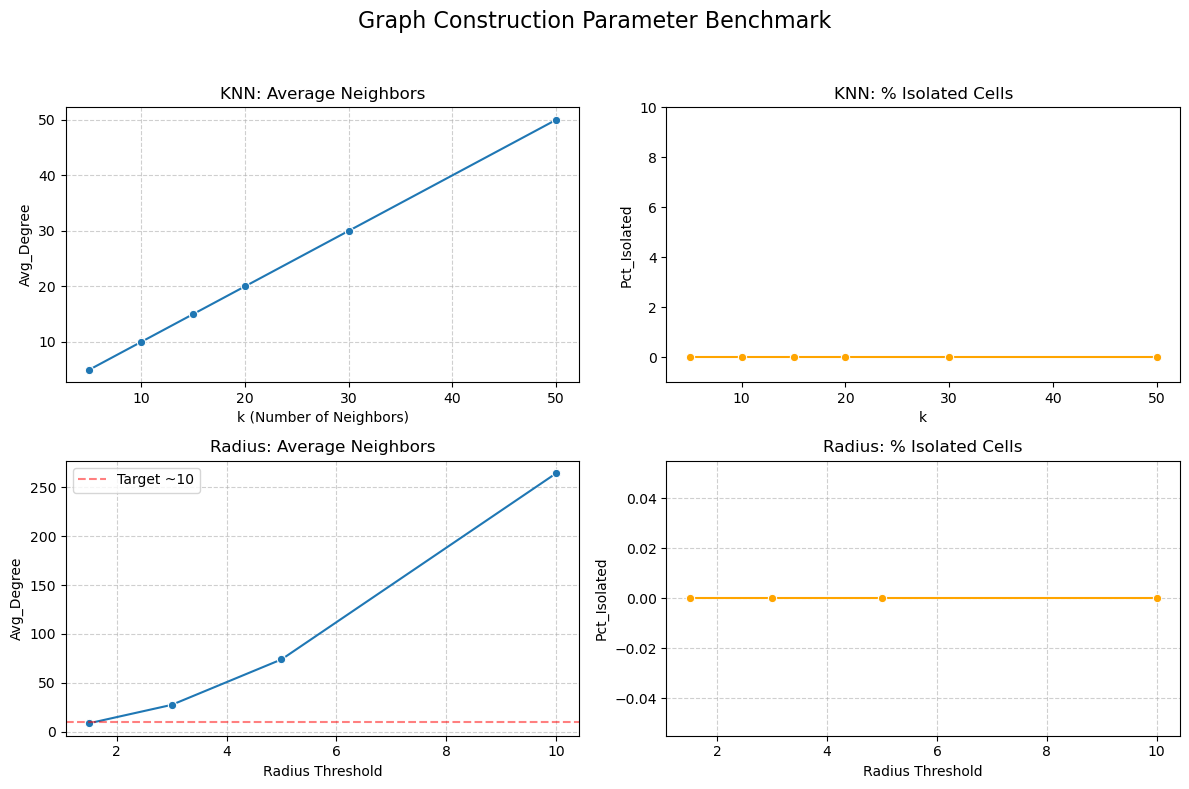


--- Radius Recommendations ---
Minimum radius for <1% isolated cells: 1.5
Detailed Stats for viable radii:
   Parameter  Avg_Degree  Pct_Isolated
6        1.5    8.738363           0.0
7        3.0   27.498395           0.0
8        5.0   73.969502           0.0
9       10.0  264.251204           0.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

def benchmark_graph_params(mdata, k_range, radius_range, spatial_key="pos"):
    if spatial_key in mdata.mod['RNA'].obsm:
        coords = mdata.mod['RNA'].obsm[spatial_key]
    else:
        raise ValueError(f"Spatial key '{spatial_key}' not found in mdata.mod['RNA'].obsm")

    results = []


    print("Benchmarking KNN...")
    nbrs_knn = NearestNeighbors(n_neighbors=max(k_range), algorithm='auto').fit(coords)
    
    for k in k_range:
        # kneighbors_graph returns an adjacency matrix (N x N)
        adj = nbrs_knn.kneighbors_graph(coords, n_neighbors=k, mode='connectivity')
        degrees = np.array(adj.sum(axis=1)).flatten()
        avg_deg = np.mean(degrees)
        pct_isolated = (np.sum(degrees == 0) / len(degrees)) * 100
        
        results.append({
            "Type": "KNN",
            "Parameter": k,
            "Avg_Degree": avg_deg,
            "Pct_Isolated": pct_isolated
        })

    print("Benchmarking Radius...")
    nbrs_rad = NearestNeighbors(radius=max(radius_range), algorithm='auto').fit(coords)
    
    for r in radius_range:
        adj = nbrs_rad.radius_neighbors_graph(coords, radius=r, mode='connectivity')
        
        degrees = np.array(adj.sum(axis=1)).flatten()
        avg_deg = np.mean(degrees)
        pct_isolated = (np.sum(degrees == 0) / len(degrees)) * 100
        
        results.append({
            "Type": "Radius",
            "Parameter": r,
            "Avg_Degree": avg_deg,
            "Pct_Isolated": pct_isolated
        })

    return pd.DataFrame(results)

def plot_benchmark_results(df):
    """
    Plots the benchmark metrics side-by-side.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Graph Construction Parameter Benchmark", fontsize=16)

    knn_df = df[df["Type"] == "KNN"]
    
    sns.lineplot(data=knn_df, x="Parameter", y="Avg_Degree", ax=axes[0, 0], marker="o")
    axes[0, 0].set_title("KNN: Average Neighbors")
    axes[0, 0].set_xlabel("k (Number of Neighbors)")
    axes[0, 0].grid(True, linestyle='--', alpha=0.6)
    
    sns.lineplot(data=knn_df, x="Parameter", y="Pct_Isolated", ax=axes[0, 1], marker="o", color="orange")
    axes[0, 1].set_title("KNN: % Isolated Cells")
    axes[0, 1].set_xlabel("k")
    axes[0, 1].set_ylim(-1, 10) # Zoom in near 0

    rad_df = df[df["Type"] == "Radius"]
    sns.lineplot(data=rad_df, x="Parameter", y="Avg_Degree", ax=axes[1, 0], marker="o")
    axes[1, 0].set_title("Radius: Average Neighbors")
    axes[1, 0].set_xlabel("Radius Threshold")
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)
    axes[1, 0].axhline(10, color='red', linestyle='--', alpha=0.5, label='Target ~10')
    axes[1, 0].legend()

    sns.lineplot(data=rad_df, x="Parameter", y="Pct_Isolated", ax=axes[1, 1], marker="o", color="orange")
    axes[1, 1].set_title("Radius: % Isolated Cells")
    axes[1, 1].set_xlabel("Radius Threshold")
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

k_test_range = [5, 10, 15, 20, 30, 50]
radius_test_range = [1.5, 3.0, 5.0, 10.0]
benchmark_df = benchmark_graph_params(mdata, k_test_range, radius_test_range, spatial_key="pos")
plot_benchmark_results(benchmark_df)
print("\n--- Radius Recommendations ---")
# Find smallest radius where isolation is low (< 1%)
viable_radii = benchmark_df[(benchmark_df["Type"]=="Radius") & (benchmark_df["Pct_Isolated"] < 1.0)]
if not viable_radii.empty:
    print(f"Minimum radius for <1% isolated cells: {viable_radii.iloc[0]['Parameter']}")
    print("Detailed Stats for viable radii:")
    print(viable_radii[["Parameter", "Avg_Degree", "Pct_Isolated"]].head())
else:
    print("No radius in range achieved <1% isolation. Try larger radii.")

In [21]:
from graph import graph_construction
import torch

rna_adata = mdata.mod['RNA']
coords = rna_adata.obsm['pos'] 

# 1. connectivy
print("Constructing Graph using Connectivity...")
for k in [6,10,30,50]:
    print(f"Constructing graph with k={k}...")
    position = rna_adata.obsm["pos"]
    mode = 'connectivity'
    e_index_conn, e_weight_conn = graph_construction(
        position, 
        k=k, 
        mode=mode
    )
    print(f"Edge Index Shape: {e_index_conn.shape}")
    print(f"Edge Weight Mean: {e_weight_conn.mean():.4f} ")
    graph_data = {
        'edge_index': e_index_conn,
        'edge_weight': e_weight_conn
    }
    save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{k}_conn.pt'
    torch.save(graph_data, save_path)
    # 2. similarity
    mode = 'similarity'
    e_index_sim, e_weight_sim = graph_construction(
        position, 
        k=k, 
        mode=mode,
        similarity_method='inverse'
    )
    print(f"Edge Index Shape: {e_index_sim.shape}")
    print(f"Edge Weight Mean: {e_weight_sim.mean():.4f} ")
    save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{k}_sim_inv.pt'
    torch.save(graph_data, save_path)
    # 3. similarity with gaussian
    e_index_sim_d, e_weight_sim_d = graph_construction( #sigma might be a parameter here.
    position, 
    k=k, 
    mode=mode,
    similarity_method='gaussian'
    )
    print(f"Edge Index Shape: {e_index_sim_d.shape}")
    print(f"Edge Weight Mean: {e_weight_sim_d.mean():.4f} ")
    save_path = f'/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{k}_sim_gau.pt'
    torch.save(graph_data, save_path)
    

Constructing Graph using Connectivity...
Constructing graph with k=6...
Edge Index Shape: torch.Size([2, 14952])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch.Size([2, 14952])
Edge Weight Mean: 0.8950 
Similarity Method: Gaussian. Using sigma=1.15
Edge Index Shape: torch.Size([2, 14952])
Edge Weight Mean: 0.6079 
Constructing graph with k=10...
Edge Index Shape: torch.Size([2, 24920])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch.Size([2, 24920])
Edge Weight Mean: 0.7738 
Similarity Method: Gaussian. Using sigma=1.39
Edge Index Shape: torch.Size([2, 24920])
Edge Weight Mean: 0.6085 
Constructing graph with k=30...
Edge Index Shape: torch.Size([2, 74760])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch.Size([2, 74760])
Edge Weight Mean: 0.5164 
Similarity Method: Gaussian. Using sigma=2.24
Edge Index Shape: torch.Size([2, 74760])
Edge Weight Mean: 0.6047 
Constructing graph with k=50...
Edge Index Shape: torch.Size([2, 124600])
Edge Weight Mean: 1.0000 
Edge Index Shape: torch

In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import torch
import scipy.sparse as sp
import os
os.environ["MKL_VERBOSE"] = "0"
os.environ["MKL_DISABLE_FAST_MM"] = "1"
import warnings
warnings.filterwarnings("ignore", message="Intel MKL")
warnings.filterwarnings("ignore", category=FutureWarning)


def compute_lisi(emb, labels, perplexity=30):
    n_neighbors = int(3 * perplexity)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(emb)
    distances, indices = nn.kneighbors(emb)
    indices = indices[:, 1:]  # drop self

    labels = np.array(labels)
    out = []

    for i in range(emb.shape[0]):
        neigh = labels[indices[i]]
        p = pd.value_counts(neigh) / len(neigh)
        entropy = -(p * np.log(p)).sum()
        out.append(np.exp(entropy))

    return np.array(out)


def compute_morani(choice, rna_adata):
    graph_choice = "5_conn" if choice == "5" else choice
    graph_path = f"/Users/momo/Documents/cs536r/spatial_totalvi/data/graph/graph_k{graph_choice}.pt"

    graph_data = torch.load(graph_path)
    edge_index = graph_data['edge_index'].cpu().numpy()   # (2, E)
    edge_weight = graph_data['edge_weight'].cpu().numpy() # (E,)
    n_cells = rna_adata.n_obs

    spatial_graph_sparse = sp.coo_matrix(
        (edge_weight, (edge_index[0], edge_index[1])),
        shape=(n_cells, n_cells)
    )

    # Replace connectivities with spatial graph
    rna_adata.obsp['connectivities'] = spatial_graph_sparse.tocsr()

    rna_moran = sc.metrics.morans_i(
        rna_adata,
        obsm="X_spatial_totalVI"   # vals = latent dims
        # use_graph=None -> uses 'connectivities' we just set
    )
    return rna_moran


# ---------- Main loop ----------
choices = [
    "5", "5_sim_gau", "5_sim_inv",
    "5_sim_gau", "6_sim_gau", "6_sim_inv",
    "10_conn", "10_sim_gau", "10_sim_inv",
    "20_sim_gau", "20_sim_inv"，
    "30_conn", "30_sim_gau", "30_sim_inv",
    "50_conn", "50_sim_gau", "50_sim_inv"
]
save_dir = "/Users/momo/Documents/cs536r/spatial_totalvi/benchmark/results"
os.makedirs(save_dir, exist_ok=True)

mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
rna_adata_base = mdata.mod["RNA"]


metrics = []  

for i, choice in enumerate(choices):
    print(f"Processing model {choice} ...")

    rna_adata = rna_adata_base.copy()

    embeddings = pd.read_table(
        f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_latents.tsv",
        header=None, sep="\t"
    ).to_numpy()

    umap_rerun = pd.read_table(
        f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_umaplatents.tsv",
        header=None, sep="\t"
    ).to_numpy()

    rna_adata.obsm["X_spatial_totalVI"] = embeddings
    rna_adata.obsm["X_umap"] = umap_rerun

    sc.pp.neighbors(rna_adata, use_rep="X_spatial_totalVI", n_neighbors=30)
    sc.tl.umap(rna_adata)

    # ---------- Moran's I ----------
    rna_moran = compute_morani(choice, rna_adata)
    mean_moran = float(rna_moran.mean())

    # ---------- Clustering ----------
    kmeans = KMeans(n_clusters=5, random_state=0).fit(embeddings)
    rna_adata.obs['kmeans5'] = kmeans.labels_.astype(str)

    sc.tl.leiden(rna_adata, key_added="leiden_eval", resolution=0.7, random_state=0)
    sc.tl.louvain(rna_adata, key_added="louvain_eval", resolution=0.7, random_state=0)

    # ---------- cLISI ----------
    cLISI_kmean   = compute_lisi(embeddings, rna_adata.obs["kmeans5"])
    cLISI_louvain = compute_lisi(embeddings, rna_adata.obs["louvain_eval"])
    cLISI_leiden  = compute_lisi(embeddings, rna_adata.obs["leiden_eval"])

    mean_cLISI_kmeans   = float(cLISI_kmean.mean())
    mean_cLISI_louvain  = float(cLISI_louvain.mean())
    mean_cLISI_leiden   = float(cLISI_leiden.mean())

    # ---------- DBI ----------
    dbi_kmeans  = float(davies_bouldin_score(embeddings, kmeans.labels_))
    dbi_louvain = float(davies_bouldin_score(embeddings, rna_adata.obs["louvain_eval"].astype(int).values))
    dbi_leiden  = float(davies_bouldin_score(embeddings, rna_adata.obs["leiden_eval"].astype(int).values))


    # ---------- Collect metrics ----------
    metrics.append({
        "model": choice,
        "mean_moran": mean_moran,
        "mean_cLISI_kmeans5": mean_cLISI_kmeans,
        "mean_cLISI_louvain": mean_cLISI_louvain,
        "mean_cLISI_leiden": mean_cLISI_leiden,
        "dbi_kmeans": dbi_kmeans,
        "dbi_louvain": dbi_louvain,
        "dbi_leiden": dbi_leiden,
    })


metrics_df = pd.DataFrame(metrics)

metrics_df.to_csv(
    os.path.join(save_dir, "graph_metrics.tsv"),
    sep="\t",
    index=False
)
metrics_df

SyntaxError: invalid character '，' (U+FF0C) (2008837297.py, line 67)

/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


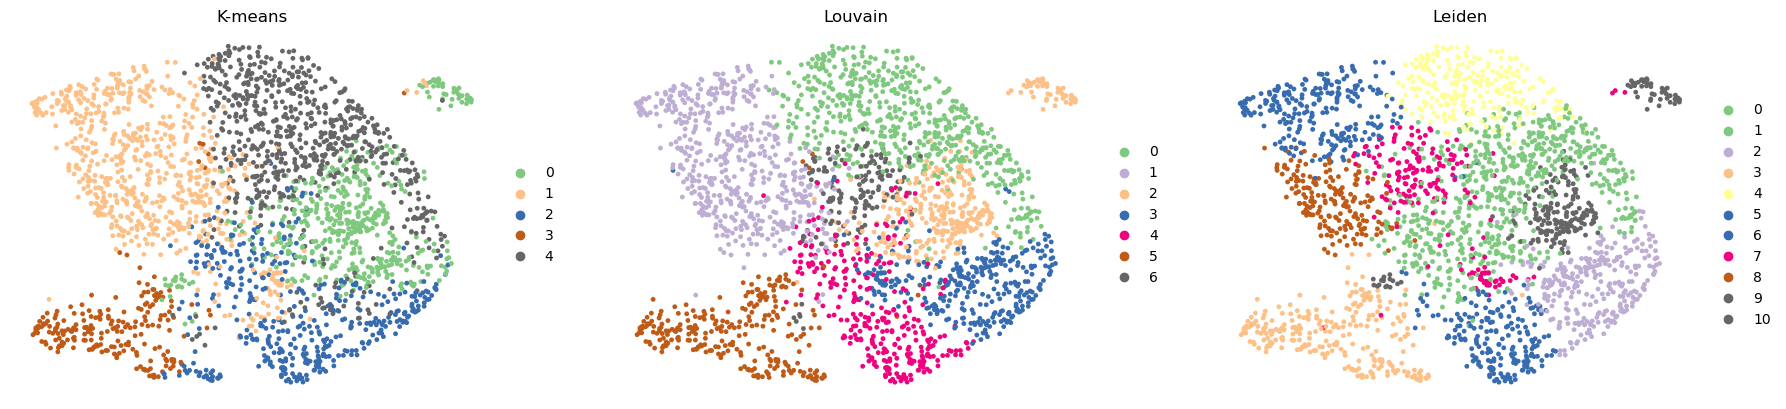

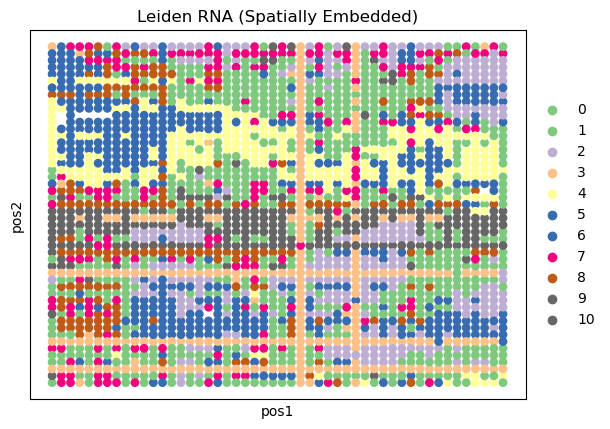

In [7]:
mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
choice="5_sim_gau"
embeddings = pd.read_table(f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_latents.tsv", header = None, sep = "\t")
umap_rerun = pd.read_table(f"../../data/latents/totalvi_k{choice}_1layer_SGC_k1_umaplatents.tsv", header = None, sep = "\t")
embeddings = embeddings.to_numpy()
umap_rerun = umap_rerun.to_numpy()
## given that embeddings will be an m x k matrix, where m = cells and k = latent dimensions, maybe can pull the mdata object and add the embeddings into obsm layer
rna_adata = mdata.mod['RNA']
rna_adata.obsm['X_spatial_totalVI'] = embeddings
# rna_adata.obsm['X_Carlos_umap'] = umap_rerun
sc.pp.neighbors(rna_adata, use_rep="X_spatial_totalVI", n_neighbors=30, metric="correlation") # it SHOULD make the umap based on this neighbor's adjacency right?
sc.tl.umap(rna_adata, min_dist=0.4)

prot_adata = mdata.mod['Protein']
prot_adata.obsm['X_spatial_totalVI'] = embeddings
# prot_adata.obsm['X_Carlos_umap'] = umap_rerun
sc.pp.neighbors(prot_adata, use_rep="X_spatial_totalVI", n_neighbors=30, metric="correlation") # it SHOULD make the umap based on this neighbor's adjacency right?
sc.tl.umap(prot_adata, min_dist=0.4)
kmeans = KMeans(n_clusters=5, random_state=0).fit(embeddings) # not sure how many clusters to create?
rna_adata.obs['kmeans5'] = kmeans.labels_.astype(str)
prot_adata.obs['kmeans5'] = kmeans.labels_.astype(str)
sc.tl.leiden(rna_adata, key_added="leiden_eval", resolution=0.7, random_state=0)
sc.tl.leiden(prot_adata, key_added="leiden_eval", resolution=0.7, random_state=0)
sc.tl.louvain(rna_adata, key_added="louvain_eval", resolution=0.7, random_state=0)
sc.tl.louvain(prot_adata, key_added="louvain_eval", resolution=0.7, random_state=0)
rna_umap = sc.pl.umap(rna_adata, layer = "X_umap",
                      color = ['kmeans5', 'louvain_eval', 'leiden_eval'], 
                      frameon = False,
                      palette = 'Accent',
                      title = ['K-means', 'Louvain', 'Leiden'],
                      return_fig=True)
rna_pos_plot = sc.pl.embedding(mdata.mod['RNA'],
                basis="pos",
                color="leiden_eval", 
                s=160,
                return_fig=True,
                title = 'Leiden RNA (Spatially Embedded)',
                palette= "Accent")

rna_pos_plot.axes[0].invert_yaxis()

/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/miniconda3/envs/mudata/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Processing model: 5...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Processing model: 20_conn...


FileNotFoundError: [Errno 2] No such file or directory

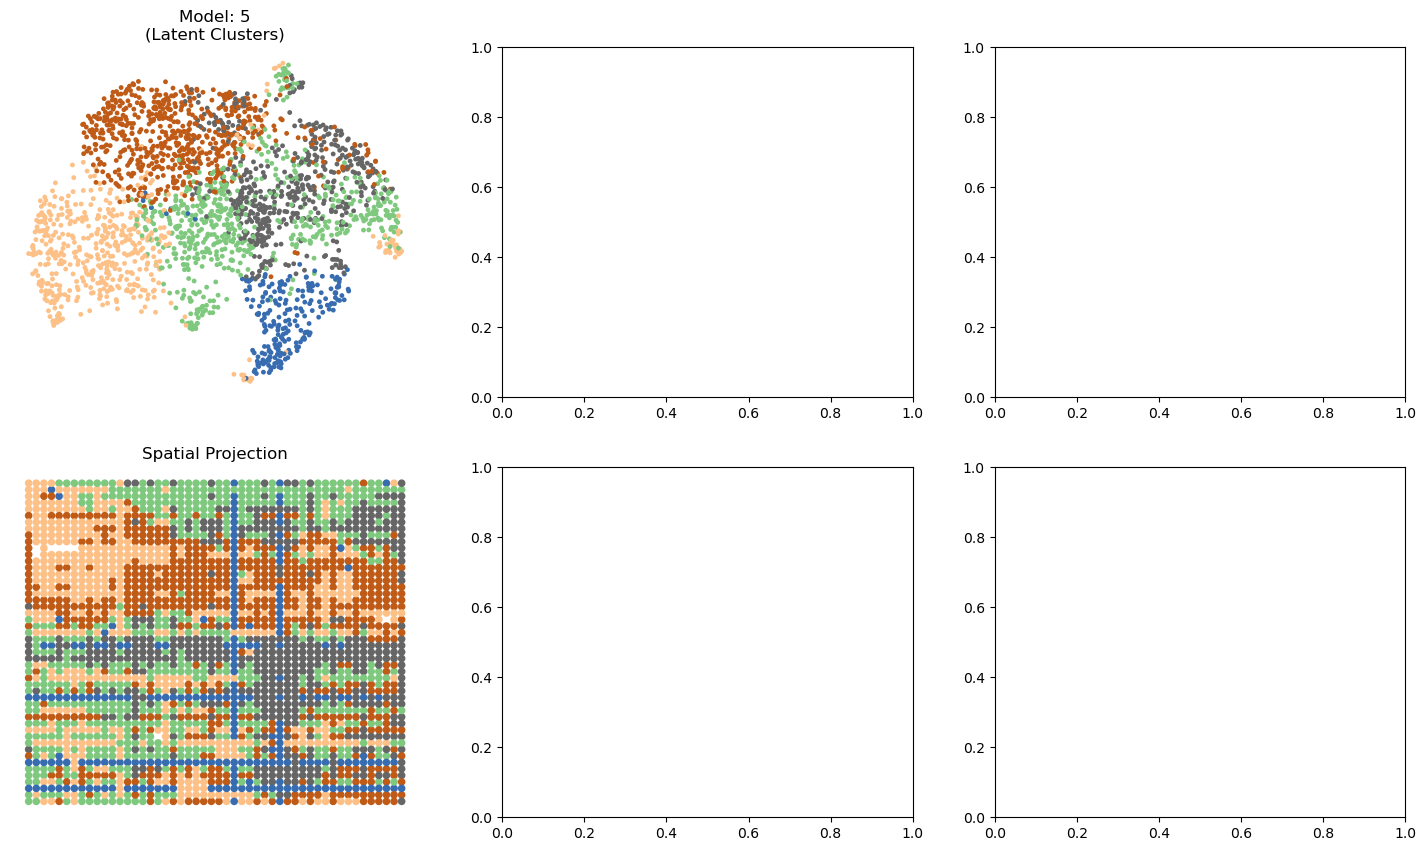

In [4]:
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import numpy as np
import mudata as md
from sklearn.cluster import KMeans

# 1. Setup
choices = ["5", "20_conn", "100_conn"]
save_dir = "/Users/momo/Documents/cs536r/spatial_totalvi/benchmark/results"

# Load the base data once
mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg2.h5mu")
# Ensure we have the spatial coordinates available. 
# Based on your snippet, they are in mdata.mod['RNA'].obsm['pos'] or 'spatial'
# We will verify this inside the loop.

# Initialize the figure: 2 Rows (UMAP, Spatial) x 3 Columns (Choices)
fig, axes = plt.subplots(nrows=2, ncols=len(choices), figsize=(18, 10))

# Titles for the rows
axes[0, 0].set_ylabel("Latent Space (UMAP)", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("Physical Space (Tissue)", fontsize=14, fontweight='bold')

for i, choice in enumerate(choices):
    print(f"Processing model: {choice}...")
    
    # --- A. Prepare Data ---
    # Create a fresh copy for this iteration so we don't overwrite previous runs
    rna_adata = mdata.mod['RNA'].copy()
    
    # Load Latents
    # (Adjust path if needed based on your file structure)
    latents_path = f"/Users/momo/Documents/cs536r/spatial_totalvi/data/latents/totalvi_k{choice}_1layer_SGC_k1_latents.tsv"
    embeddings = pd.read_table(latents_path, header=None, sep="\t").to_numpy()
    #/Users/momo/Documents/cs536r/spatial_totalvi/data/latents/totalvi_k5_sim_gau_1layer_SGC_k1_umaplatents.tsv
    # Assign Latents
    rna_adata.obsm['X_spatial_totalVI'] = embeddings
    
    # --- B. Clustering (K-Means only) ---
    kmeans = KMeans(n_clusters=5, random_state=0).fit(embeddings)
    rna_adata.obs['kmeans5'] = kmeans.labels_.astype(str)
    
    # --- C. Run UMAP ---
    # As per your snippet: calculate neighbors on the latents, then run UMAP
    sc.pp.neighbors(rna_adata, use_rep="X_spatial_totalVI", n_neighbors=30, metric="correlation")
    sc.tl.umap(rna_adata, min_dist=0.4)
    
    # --- D. Plotting ---
    
    # Row 1: UMAP of Latents
    sc.pl.embedding(
        rna_adata,
        basis="X_umap",
        color="kmeans5",
        ax=axes[0, i],
        show=False,
        palette="Accent",      # Consistent color palette
        frameon=False,
        title=f"Model: {choice}\n(Latent Clusters)",
        legend_loc="none"      # Remove legend to save space (optional)
    )
    
    # Row 2: Spatial Map (Physical Coordinates)
    # Note: Your snippet uses basis="pos". Ensure 'pos' is in obsm.
    if "pos" not in rna_adata.obsm:
        # Fallback: sometimes it's stored in 'spatial'
        if "spatial" in rna_adata.obsm:
            rna_adata.obsm['pos'] = rna_adata.obsm['spatial']
            
    sc.pl.embedding(
        rna_adata,
        basis="pos",
        color="kmeans5",
        ax=axes[1, i],
        show=False,
        palette="Accent",      # MUST use same palette to match colors top-to-bottom
        frameon=False,
        title="Spatial Projection",
        s=120,                 # Adjust dot size (160 might be too big for subplots)
        legend_loc="none"
    )
    
    # Invert Y-axis for spatial plot (standard for Visium/Microscopy)
    axes[1, i].invert_yaxis()

# --- E. Finalize ---
plt.suptitle("K-Means Clustering Comparison: Latent vs Spatial Structure", fontsize=16, y=1.02)
plt.tight_layout()

# Save
plt.savefig("kmeans_comparison_loop.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
import os
import pandas as pd
import numpy as np

# 1. 定义你的项目根目录 (直接把你的路径写死，最稳妥)
PROJECT_ROOT = "/Users/momo/Documents/cs536r/spatial_totalvi"

# 2. 检查一下路径对不对 (这一步是调试用的)
print(f"Project Root: {PROJECT_ROOT}")

# 3. 这里的 choice 必须和你的文件名里的字符串完全一致
# 你的文件名是: totalvi_k5_sim_gau_1layer_SGC_k1_latents.tsv
# 所以 choice 应该是 "5_sim_gau"
choice = "100_conn"  
latents_path = os.path.join(PROJECT_ROOT, "data/latents", f"totalvi_k{choice}_1layer_SGC_k1_latents.tsv")
# 5. 读取前先检查文件是否存在
if os.path.exists(latents_path):
    print(f"✅ Found file: {latents_path}")
    embeddings = pd.read_table(latents_path, header=None, sep="\t").to_numpy()
else:
    print(f"❌ File NOT found: {latents_path}")
    # 列出 latents 文件夹里到底有什么，方便你检查是不是文件名拼写错了
    latents_dir = os.path.join(PROJECT_ROOT, "data/latents")
    if os.path.exists(latents_dir):
        print("Files in directory:", os.listdir(latents_dir))

Project Root: /Users/momo/Documents/cs536r/spatial_totalvi
✅ Found file: /Users/momo/Documents/cs536r/spatial_totalvi/data/latents/totalvi_k100_conn_1layer_SGC_k1_latents.tsv
